In [ ]:
df =pd.read_excel("Urban_Traffic_Data.xlsx")

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score


In [ ]:
df.head(5)

,City,Year,Average_Daily_Traffic_Counts,Peak_Hourly_Traffic_Volume,Percentage_of_Commercial_Vehicles,Number_of_Road_Accidents,Average_Traffic_Speed_kmh,Air_Quality_Index,Population_Million
0,New York,2015,19967,4705,15.3,159,30.7,113,11.24
1,London,2015,22128,3408,15.4,609,71.7,85,12.37
2,Tokyo,2015,44738,2017,9.1,775,52.3,53,11.97
3,Mumbai,2015,38295,4140,19.2,614,72.7,72,10.55
4,Sydney,2015,30337,4654,14.9,114,29.1,74,7.16


In [ ]:
df=pd.read_excel("Urban_Traffic_Data.xlsx")

In [ ]:
df["City"]=df["City"].astype("category").cat.codes
X=df[["City","Year","Peak_Hourly_Traffic_Volume","Percentage_of_Commercial_Vehicles","Number_of_Road_Accidents","Average_Traffic_Speed_kmh","Air_Quality_Index","Population_Million"]]
y=df["Average_Daily_Traffic_Counts"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
model=KNeighborsRegressor(n_neighbors=5)
model.fit(X_train,y_train)


KNeighborsRegressor()

In [ ]:
y_pred=model.predict(X_test)
print("R2 Score:",r2_score(y_test,y_pred))
print("Mean Squared Error:",mean_squared_error(y_test,y_pred))



R2 Score: -0.023869069047504077
Mean Squared Error: 110036384.63333336


In [ ]:
low=y.quantile(0.33)
high=y.quantile(0.67)
prediction_value=model.predict([X_test.iloc[0].tolist()])[0]

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsRegressor was fitted with feature names
  warnings.warn(


In [ ]:
if prediction_value<=low:
    level ="Low Traffic"
elif prediction_value>high:
     level ="High Traffic"
else:
     level ="Medium Traffic"

In [ ]:
print("predication Traffic Count",prediction_value)
print("Traffic Level:",level)

predication Traffic Count 30953.4
Traffic Level: Medium Traffic


for graph

In [ ]:
df =pd.read_excel("Urban_Traffic_Data.xlsx")

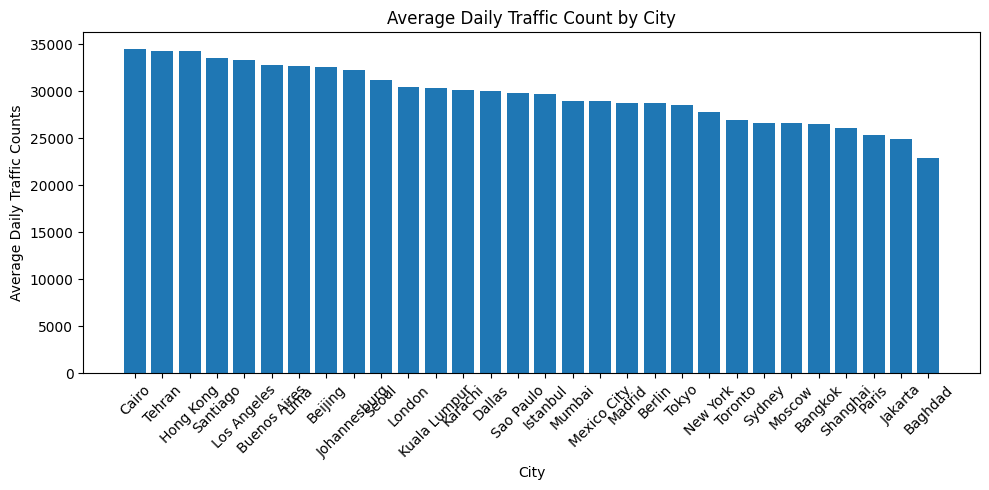

In [ ]:
city_avg = df.groupby("City")["Average_Daily_Traffic_Counts"].mean().sort_values(ascending=False)
plt.figure(figsize=(10,5))
plt.bar(city_avg.index, city_avg.values)
plt.title("Average Daily Traffic Count by City")
plt.xlabel("City")
plt.ylabel("Average Daily Traffic Counts")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()